In [1]:
import re
from pprint import pprint,pformat #Saubere JSON darstellung
import os
import json

import numpy as np 
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from collections import defaultdict
from collections import Counter

import spacy # Lemmatizer

import pandas as pd
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import TruncatedSVD, LatentDirichletAllocation

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from GerVADER.vaderSentimentGER import SentimentIntensityAnalyzer as GerSentimentIntensityAnalyzer

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from src.styles import *
from src.visualization import *
from src.preprocessing import *

import ipywidgets as widgets

In [24]:
def vectorize(Vectorizer, data_by_lang):
    params = {
        "ngram_range": (1, 2),
        "min_df": 3,
        "max_df": 0.8,
        "dtype": np.float32,
    }

    results = {}

    for lang, data in data_by_lang.items():
        documents = data["documents"]

        vectorizer = Vectorizer(**params)
        matrix = vectorizer.fit_transform(documents)

        results[lang] = {
            "matrix": matrix,
            "vectorizer": vectorizer,
            "feature_names": vectorizer.get_feature_names_out(),
            "documents": documents,
            "sentences": data["sentences"],
            "vocabulary": data["vocabulary"],
            "index": data["index"]
        }

        print(f"{lang}: {matrix.shape[0]} Dokumente, {matrix.shape[1]} Features")

    return results


def build_sentiment_df(model_result, lang, pos=0.05, neg=-0.05):
    """
    Berechnet Sentiment Score + Label pro Dokument.

    Parameter:
        model_result: enthält 'documents'
        lang: 'de' oder 'en'
        pos/neg: Schwellenwerte für Klassifikation

    Rückgabe:
        DataFrame mit:
        - document
        - sentiment_score
        - sentiment_label
    """

    analyzer_en = SentimentIntensityAnalyzer()
    analyzer_de = GerSentimentIntensityAnalyzer()
    
    documents = model_result["documents"]

    # richtigen Analyzer wählen
    if lang == "en":
        analyzer = analyzer_en
    elif lang == "de":
        analyzer = analyzer_de
    else:
        raise ValueError("Unsupported language")

    # Scores berechnen
    scores = [
        analyzer.polarity_scores(doc)["compound"]
        for doc in documents
    ]

    # DataFrame erstellen
    df = pd.DataFrame({
        "document": documents,
        "sentiment_score": scores
    })

    # Label direkt inline
    df["sentiment_label"] = df["sentiment_score"].apply(
        lambda s: "positive" if s >= pos else "negative" if s <= neg else "neutral"
    )

    return df


In [3]:
##########
# Data Import
##########

# Variable Definition
local_dir = "data"
path_reviews = f"{local_dir}/combined_reviews.csv"
stopword_path = "data/stopwords_custom.json"

top_n = 15
n_process = 1

# Import data to pandas dataframe
df_reviews = pd.read_csv(path_reviews)

df_reviews["language"] = df_reviews["origin"].map({
    "FragdenStaat": "de",
    "YELP": "en",
})

##########
# Stopword Definition
##########

# Basis-Dictionary
dict_stopw_default = {
    "iter_0": {
        "de_nltk_common": stopwords.words("german"),
        "en_nltk_common": stopwords.words("english")
    },
    "iter_1": {
        "de_custom_common": [],
        "de_custom_topic_only": [],
        "en_custom_common": [],
        "en_custom_topic_only": []
    }
}


while True:
    # Stopwörter JSON laden oder neu erstellen
    if os.path.exists(stopword_path) and os.path.getsize(stopword_path) > 0:
        print("Stopwort-Datei gefunden -> wird eingelesen")
        dict_stopw = load_stopw_from_json(stopword_path)

        if "iter_0" not in dict_stopw:
            dict_stopw["iter_0"] = dict_stopw_default["iter_0"]
            write_stopw_to_json(dict_stopw, stopword_path)

    else:
        print("Stopwort-Datei fehlt oder ist leer -> wird erstellt")
        dict_stopw = dict_stopw_default
        write_stopw_to_json(dict_stopw, stopword_path)

    # Stopwörter zusammenführen
    stopwords_all = build_stopword_lists_from_iterations(dict_stopw)

    stopw_topic_de = stopwords_all["topic_de"]
    stopw_sentiment_de = stopwords_all["sentiment_de"]

    stopw_topic_en = stopwords_all["topic_en"]
    stopw_sentiment_en = stopwords_all["sentiment_en"]

    # Cleaning Topic
    print("\nCleaning Data - Topic Modeling")
    data_topic = clean_and_tokenize(
        df_reviews,
        stopw_de=stopw_topic_de,
        stopw_en=stopw_topic_en,
        n_process=n_process
    )

    # Cleaning Sentiment
    print("\nCleaning Data - Sentiment Analysis")
    data_sentiment = clean_and_tokenize(
        df_reviews,
        stopw_de=stopw_sentiment_de,
        stopw_en=stopw_sentiment_en,
        n_process=n_process
    )

    # Vergleichstabelle anzeigen
    compare_top_tokens_table = compare_top_tokens(
        data_topic,
        data_sentiment,
        top_n
    )
    print()
    display(
        style_compare_top_tokens(
            compare_top_tokens_table,
            caption=f"Vergleich Top {top_n} Token (de/en)"
        )
    )

    current_iter = get_current_iteration_key(dict_stopw)
    
    print(
        f"\nBitte Top Token prüfen und ggf. unter '{current_iter}' in {stopword_path} ergänzen."
    )
    print("1 = JSON ergänzt, nächste Iteration starten")
    print("2 = fertig, weiter mit Topic Modeling")
    
    choice = input("Auswahl: ").strip()
    
    if choice == "1":
        # JSON neu laden (mit deinen Ergänzungen)
        dict_stopw = load_stopw_from_json(stopword_path)
    
        # nächste Iteration vorbereiten
        dict_stopw = add_iter_to_json(stopword_path)
    
    elif choice == "2":
        print("\nFinale Stopwörter übernommen. Weiter mit Topic Modeling.")
        break
    
    else:
        print("\nUngültige Eingabe. Bitte 1 oder 2 wählen.")
		

Stopwort-Datei gefunden -> wird eingelesen

Cleaning Data - Topic Modeling


Englisch verarbeiten: 100%|████████████████████████████████████████████████████████| 1000/1000 [00:11<00:00, 86.92it/s]



Cleaning Data - Sentiment Analysis


Englisch verarbeiten: 100%|████████████████████████████████████████████████████████| 1000/1000 [00:11<00:00, 88.91it/s]



Bitte Top Token prüfen und ggf. unter 'iter_6' in data/stopwords_custom.json ergänzen.
1 = JSON ergänzt, nächste Iteration starten
2 = fertig, weiter mit Topic Modeling


Auswahl:  2



Finale Stopwörter übernommen. Weiter mit Topic Modeling.


In [4]:
############
# Create Vectors with BoW & TF-IDF
# Separate Pipelines: Topic Modeling vs. Sentiment
############

print("Creating Vectors - Topic Modeling")
vectors_topic = {}
vectors_topic["bow_by_lang"] = vectorize(CountVectorizer, data_topic)
vectors_topic["tfidf_by_lang"] = vectorize(TfidfVectorizer, data_topic)

print("\nCreating Vectors - Sentiment Analysis")
vectors_sentiment = {}
vectors_sentiment["bow_by_lang"] = vectorize(CountVectorizer, data_sentiment)
vectors_sentiment["tfidf_by_lang"] = vectorize(TfidfVectorizer, data_sentiment)


Creating Vectors - Topic Modeling
de: 1000 Dokumente, 3761 Features
en: 1000 Dokumente, 2416 Features
de: 1000 Dokumente, 3761 Features
en: 1000 Dokumente, 2416 Features

Creating Vectors - Sentiment Analysis
de: 1000 Dokumente, 3761 Features
en: 1000 Dokumente, 2641 Features
de: 1000 Dokumente, 3761 Features
en: 1000 Dokumente, 2641 Features


In [19]:
############
# Topic Modeling
############

# Zentrale Parameter für alle Topic-Modelle
n_topics = 10          # Anzahl der Topics
n_top_words = 15       # Anzahl der Top-Wörter pro Topic
max_iter = 20          # Anzahl der Trainingsdurchläufe für LDA
batch_size = 500       # Batch-Größe für das Online-Learning bei LDA

# Zentrale Konfiguration aller Topic-Modelle
methods = {
    "bow_lda": {
        "title": "LDA BoW",
        "vectors_by_lang": vectors_topic["bow_by_lang"],
        "method_type": "lda",
    },
#    "tfidf_lda": {
#        "title": "LDA TF-IDF",
#        "vectors_by_lang": vectors_topic["tfidf_by_lang"],
#        "method_type": "lda",
#    },
    "tfidf_lsa": {
        "title": "LSA TF-IDF",
        "vectors_by_lang": vectors_topic["tfidf_by_lang"],
        "method_type": "lsa",
    },
}

# Jedes konfigurierte Modell trainieren
for method_key, config in methods.items():

    # Hier werden die trainierten Ergebnisse je Sprache gespeichert
    config["topics_by_lang"] = {}

    # Sprachgetrenntes Training, für "de" und "en"
    for lang, data in config["vectors_by_lang"].items():
        X = data["matrix"]  # Dokument-Term-Matrix der jeweiligen Sprache

        # LDA-Modell trainieren - Für BoW und TF-IDF mit den selben Werten
        if config["method_type"] == "lda":
            model = LatentDirichletAllocation(
                n_components=n_topics,
                random_state=42,
                learning_method="online",
                max_iter=max_iter,
                evaluate_every=-1,
                batch_size = batch_size
            )

            # Manuelles Online-Training über mehrere Iterationen und Batches
            for _ in tqdm(range(max_iter), desc=f'{config["title"]} Topic trainieren ({lang})'):
                for i in range(0, X.shape[0], batch_size):
                    model.partial_fit(X[i:i + batch_size])

            # Dokumente in Topic-Wahrscheinlichkeiten transformieren
            topic_matrix = model.transform(X)

        # LSA-Modell trainieren
        elif config["method_type"] == "lsa":
            model = TruncatedSVD(
                n_components=n_topics,
                random_state=42
            )

            # Dokumente direkt in latente Topic-Komponenten transformieren
            topic_matrix = model.fit_transform(X)
            print(f'{config["title"]} Topic trainiert ({lang})')


        # Modell- und Ergebnisdaten zentral im methods-Dict speichern
        config["topics_by_lang"][lang] = {
            "model": model,
            "doc_topic_matrix": topic_matrix,
            "matrix": X,
            "features": data["feature_names"],
            "documents": data["documents"]
        }


LDA BoW Topic trainieren (en): 100%|███████████████████████████████████████████████████| 20/20 [00:03<00:00,  5.83it/s]


LSA TF-IDF Topic trainiert (de)
LSA TF-IDF Topic trainiert (en)


In [30]:
############
# Topic + Sentiment Analyse
############

# 1. Topic-Zuordnung je Modell
doc_topics = {}

for method_key, config in methods.items():
    doc_topics[method_key] = {}

    for lang, result in config["topics_by_lang"].items():

        doc_topic_matrix = result["doc_topic_matrix"]
        documents = result["documents"]
        method_type = config["method_type"]

        # --------------------
        # Dominantes Topic je Dokument
        # --------------------
        if method_type == "lda":
            dominant_topics = doc_topic_matrix.argmax(axis=1)
            topic_strengths = doc_topic_matrix.max(axis=1)

        elif method_type == "lsa":
            dominant_topics = np.abs(doc_topic_matrix).argmax(axis=1)
            topic_strengths = np.abs(doc_topic_matrix).max(axis=1)

        # --------------------
        # DataFrame je Dokument
        # --------------------
        df_topics = pd.DataFrame({
            "document": documents,
            "dominant_topic": dominant_topics + 1,
            "topic_strength": topic_strengths
        })

        doc_topics[method_key][lang] = df_topics


# 2. Sentiment je Sprache berechnen
# Sentiment wird nur anhand TFIDF Vektor berechnet
sentiments = {
    lang: build_sentiment_df(result, lang=lang)
    for lang, result in vectors_topic["tfidf_by_lang"].items()
}

# 3. Topic-Zuordnung + Sentiment verbinden
doc_topics_sentiment = {
    method: {
        lang: df_topics.merge(
            sentiments[lang],
            on="document",
            how="left"
        )
        for lang, df_topics in lang_results.items()
    }
    for method, lang_results in doc_topics.items()
}

# 4. Aggregierte Topic/Sentiment-Tabelle je Modell
topic_sentiment_summary = {
    method: {
        lang: (
            df.groupby("dominant_topic")
            .agg(
                documents=("document", "count"),
                avg_topic_strength=("topic_strength", "mean"),
                avg_sentiment=("sentiment_score", "mean"),
                positive=("sentiment_label", lambda x: (x == "positive").sum()),
                neutral=("sentiment_label", lambda x: (x == "neutral").sum()),
                negative=("sentiment_label", lambda x: (x == "negative").sum())
            )
            .reset_index()
        )
        for lang, df in lang_results.items()
    }
    for method, lang_results in doc_topics_sentiment.items()
}

# 5. Ausgabe: Topic + Sentiment je Modell und Sprache
for lang in ["de", "en"]:

    if lang == "de":
        pos_threshold, neg_threshold = 0.5, -0.5
    elif lang == "en":
        pos_threshold, neg_threshold = 0.1, -0.1

    for method_key, config in methods.items():
        display(
            style_topic_sentiment(
                topic_sentiment_summary[method_key][lang],
                f"{config['title']} ({lang}) - Topic & Sentiment Matrix",
                pos_threshold=pos_threshold,
                neg_threshold=neg_threshold
            )
        )

dominant_topic,documents,avg_topic_strength,avg_sentiment,positive,neutral,negative
1,3776,0.984946,0.508343,3764,2,10
2,48,0.849371,0.674235,36,11,1
3,110,0.696159,0.363292,67,28,15
4,9026,0.985415,-0.862404,0,1,9025
5,99,0.770094,0.385757,77,12,10
6,235,0.643996,0.382771,167,27,41
7,227,0.905442,0.709550,185,35,7
8,179,0.675367,0.399892,121,31,27
9,357,0.950700,0.154661,90,264,3
10,335,0.964576,0.466039,329,5,1


dominant_topic,documents,avg_topic_strength,avg_sentiment,positive,neutral,negative
1,9031,0.999326,-0.861694,4,2,9025
2,3395,0.980409,0.523982,3377,6,12
3,528,0.150675,0.462750,403,67,58
4,90,0.738080,0.457347,80,8,2
5,326,0.544213,0.060053,42,267,17
6,45,0.362580,0.053787,7,36,2
7,84,0.257629,0.528338,68,5,11
8,206,0.881206,0.167028,200,2,4
9,332,0.799956,0.339610,328,4,0
10,355,0.342514,0.799726,327,19,9


dominant_topic,documents,avg_topic_strength,avg_sentiment,positive,neutral,negative
1,89,0.531825,0.395955,64,8,17
2,69,0.555159,0.454529,49,8,12
3,78,0.527977,0.541526,61,4,13
4,197,0.527958,0.484765,148,19,30
5,62,0.534516,0.409165,42,3,17
6,90,0.521813,0.442306,69,7,14
7,85,0.470292,0.464733,65,6,14
8,84,0.536005,0.505258,65,7,12
9,138,0.527209,0.443837,103,11,24
10,108,0.572700,0.295956,71,6,31


dominant_topic,documents,avg_topic_strength,avg_sentiment,positive,neutral,negative
1,615,0.150198,0.475070,469,31,115
2,76,0.161781,0.470097,57,6,13
3,39,0.337140,0.410046,28,2,9
4,28,0.279655,0.560018,24,2,2
5,40,0.190417,0.257565,26,3,11
6,33,0.157810,0.387615,21,8,4
7,12,0.220813,0.255883,7,1,4
8,46,0.146519,0.320789,29,6,11
9,37,0.136101,0.428351,25,9,3
10,74,0.146095,0.382911,51,11,12


In [29]:
# 6. Ausgabe: Topics per Method/ Language
topic_table_de = build_topic_comparison_tables(doc_topics,methods,"de")
topic_table_en = build_topic_comparison_tables(doc_topics,methods,"en")

#display(style_topic_comparison(topic_table_de, "Topic Vergleich - DE"))
#print()
display(style_topic_comparison(topic_table_en, "Topic Vergleich - EN"))

KeyError: 'Column not found: topic_keywords'

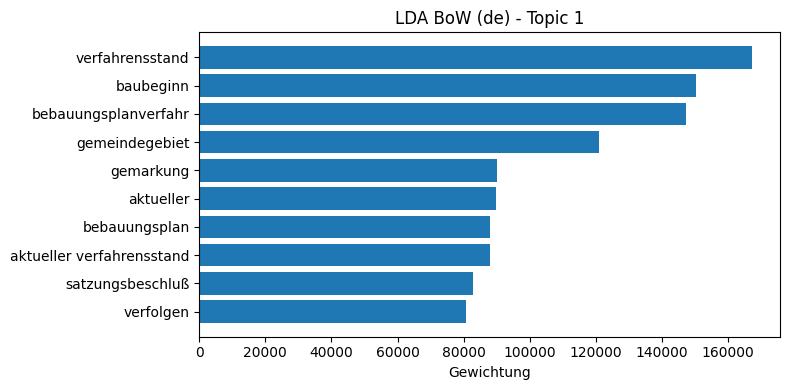

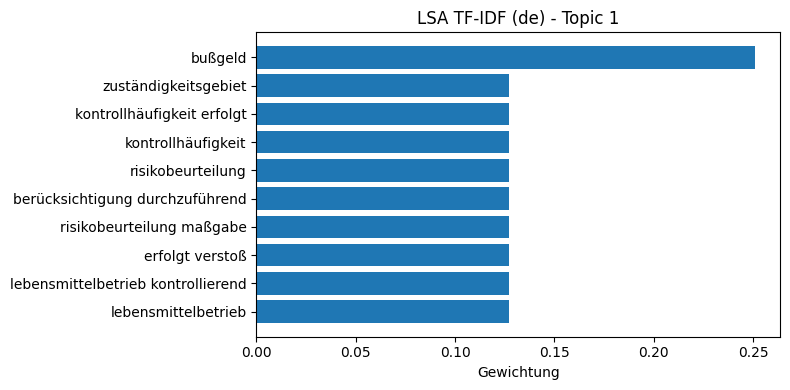

In [27]:
def plot_top_words_from_methods(methods, method_key, lang, topic_id, n_words=10):
    data = methods[method_key]["topics_by_lang"][lang]

    model = data["model"]
    features = data["features"]

    weights = model.components_[topic_id]
    top_idx = weights.argsort()[-n_words:][::-1]

    words = [features[i] for i in top_idx]
    values = [weights[i] for i in top_idx]

    plt.figure(figsize=(8, 4))
    plt.barh(words[::-1], values[::-1])
    plt.title(f'{methods[method_key]["title"]} ({lang}) - Topic {topic_id + 1}')
    plt.xlabel("Gewichtung")
    plt.tight_layout()
    plt.show()

plot_top_words_from_methods(methods, "bow_lda", "de", topic_id=0)
plot_top_words_from_methods(methods, "tfidf_lsa", "de", topic_id=0)


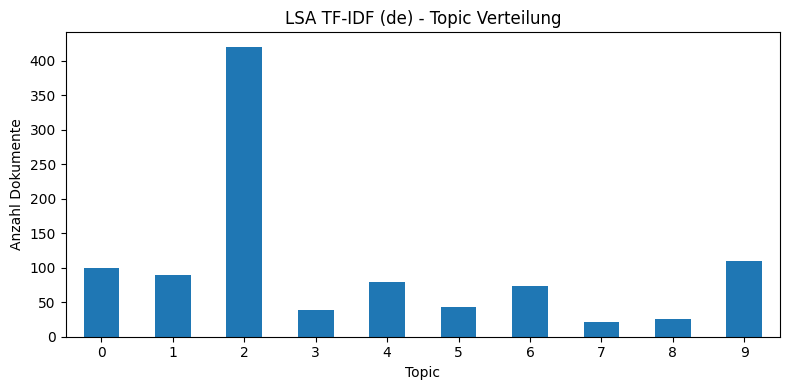

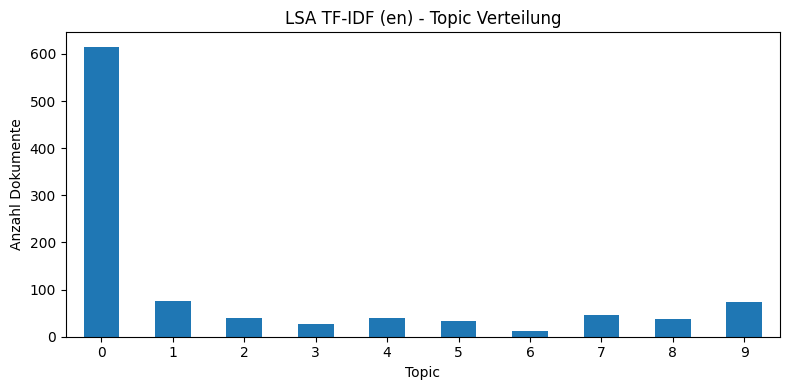

In [28]:
def plot_topic_distribution_from_methods(methods, method_key, lang):
    data = methods[method_key]["topics_by_lang"][lang]
    doc_topic_matrix = data["doc_topic_matrix"]

    if methods[method_key]["method_type"] == "lsa":
        doc_topic_matrix = np.abs(doc_topic_matrix)

    dominant_topics = doc_topic_matrix.argmax(axis=1)

    counts = (
        pd.Series(dominant_topics)
        .value_counts()
        .sort_index()
    )

    plt.figure(figsize=(8, 4))
    counts.plot(kind="bar")
    plt.title(f'{methods[method_key]["title"]} ({lang}) - Topic Verteilung')
    plt.xlabel("Topic")
    plt.ylabel("Anzahl Dokumente")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

plot_topic_distribution_from_methods(methods, "tfidf_lsa", "de")
plot_topic_distribution_from_methods(methods, "tfidf_lsa", "en")


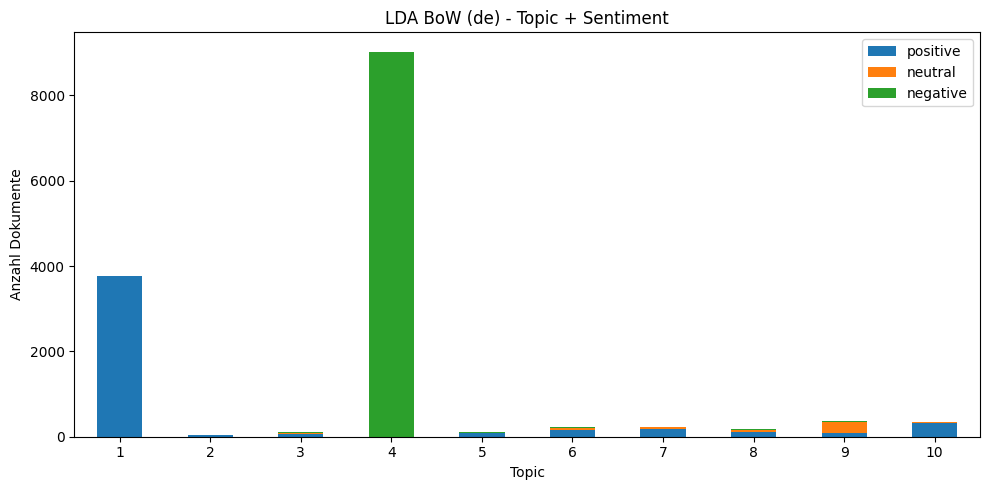

In [17]:
def plot_topic_sentiment_from_summary(summary, method_key, lang):
    df = summary[method_key][lang]

    plot_df = df.set_index("dominant_topic")[[
        "positive", "neutral", "negative"
    ]]

    plot_df.plot(
        kind="bar",
        stacked=True,
        figsize=(10, 5)
    )

    plt.title(f'{methods[method_key]["title"]} ({lang}) - Topic + Sentiment')
    plt.xlabel("Topic")
    plt.ylabel("Anzahl Dokumente")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

plot_topic_sentiment_from_summary(topic_sentiment_summary, "bow_lda", "de")

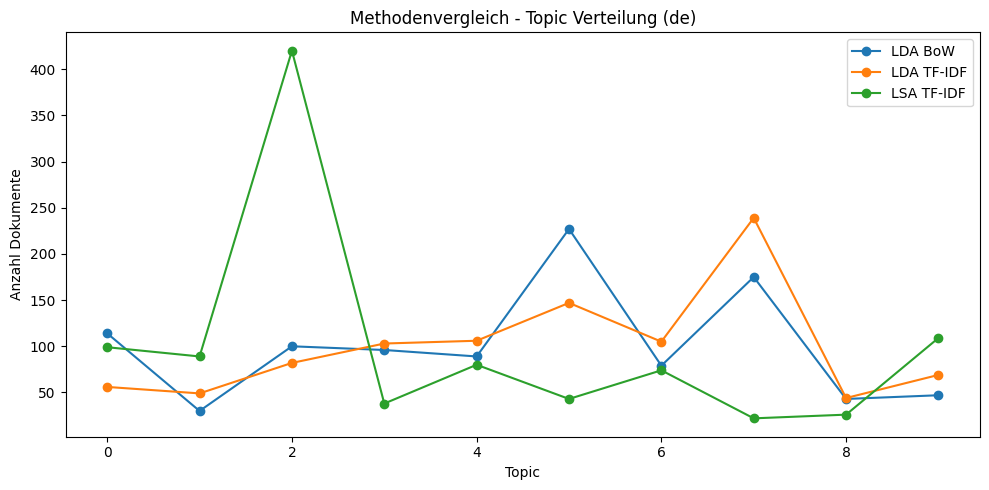

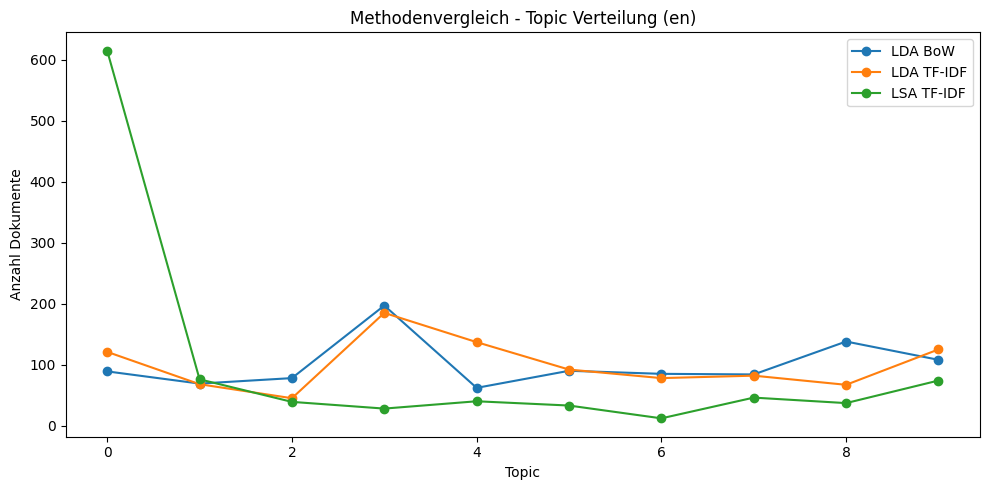

In [18]:
def compare_methods_topic_distribution(methods, lang):
    plt.figure(figsize=(10, 5))

    for method_key, config in methods.items():
        data = config["topics_by_lang"][lang]
        doc_topic_matrix = data["doc_topic_matrix"]

        if config["method_type"] == "lsa":
            doc_topic_matrix = np.abs(doc_topic_matrix)

        dominant_topics = doc_topic_matrix.argmax(axis=1)
        counts = pd.Series(dominant_topics).value_counts().sort_index()

        plt.plot(counts.index, counts.values, marker="o", label=config["title"])

    plt.title(f"Methodenvergleich - Topic Verteilung ({lang})")
    plt.xlabel("Topic")
    plt.ylabel("Anzahl Dokumente")
    plt.legend()
    plt.tight_layout()
    plt.show()

compare_methods_topic_distribution(methods, "de")
compare_methods_topic_distribution(methods, "en")